In [215]:
import cv2
import numpy as np
import torch
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
from skimage import segmentation


In [232]:
crop_settings_0 = np.load("/work/com-304/datasets/clevr_com_304/train/crop_settings/00001.npy")
path = "/scratch/tmaillar/rgb/train/point_50_view_0_domain_rgb.png"
rgb_img = Image.open(path).convert("RGB")
# image = cv2.imread(path)
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

aug_idx = 1
x1, y1, x2, y2, flip = crop_settings_0[aug_idx]
top, left, h, w = y1, x1, (y2 - y1), (x2 - x1)
cropped = TF.crop(rgb_img, top, left, h, w)
resized = cropped.resize((256, 256), resample=Image.BILINEAR)
if flip:
    resized = TF.hflip(resized)

resized_numpy = np.array(resized)

In [233]:
def show_SAM(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

def show_SAM_Canny(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0

    LOW, HIGH = 100, 200

    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask

        # Canny on the binary mask of each segment
        mask_uint8 = (m * 255).astype(np.uint8)
        edges = cv2.Canny(mask_uint8, LOW, HIGH)
        r, c = np.where(edges > 0)
        img[r, c] = np.array([0, 0, 1, 1])  # blue lines

    ax.imshow(img)

def show_Canny(anns, low=100, high=200):
    if len(anns) == 0:
        return None
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    h, w = sorted_anns[0]['segmentation'].shape
    binary = np.zeros((h, w), dtype=np.uint8)
    for ann in sorted_anns:
        m = ann['segmentation']
        mask_uint8 = (m * 255).astype(np.uint8)
        edges = cv2.Canny(mask_uint8, low, high)
        binary[edges > 0] = 255
    return binary

In [234]:
device = "cuda"
sam_checkpoint = "/scratch/tmaillar/sam_vit_h_4b8939.pth"
model_type = "default"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
mask_generator = SamAutomaticMaskGenerator(
    sam,
    pred_iou_thresh=0.88,     
    stability_score_thresh=0.95,
    min_mask_region_area=5000,    # default 0 
    points_per_side=15,          # default 32
)

masks = mask_generator.generate(resized_numpy)

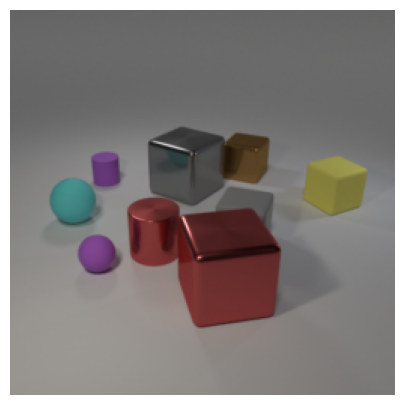

In [235]:
plt.figure(figsize=(5,5))
plt.imshow(resized)
plt.axis('off')
plt.show() 

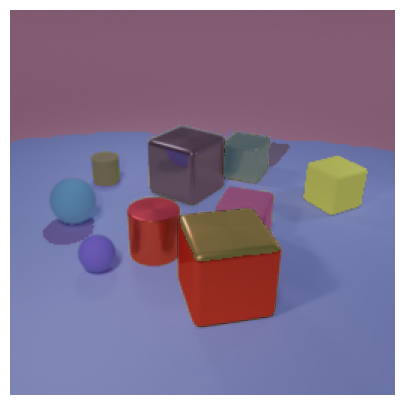

In [236]:
plt.figure(figsize=(5,5))
plt.imshow(resized)
show_SAM(masks)
plt.axis('off')
plt.show() 

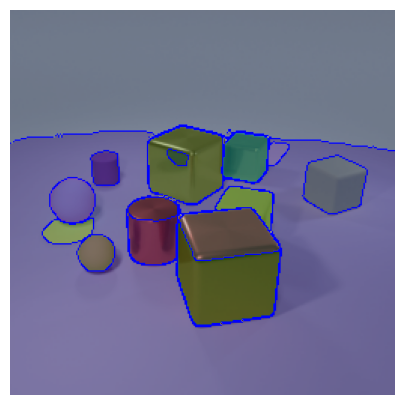

In [237]:
plt.figure(figsize=(5,5))
plt.imshow(resized)
show_SAM_Canny(masks)
plt.axis('off')
plt.show() 

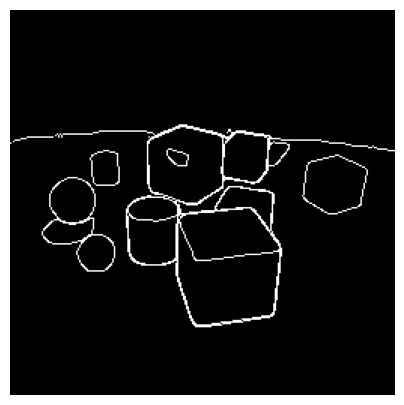

In [238]:
binary_canny = get_binary_canny(masks)
plt.figure(figsize=(5, 5))
plt.imshow(binary_canny, cmap='gray')
plt.axis('off')
plt.show()

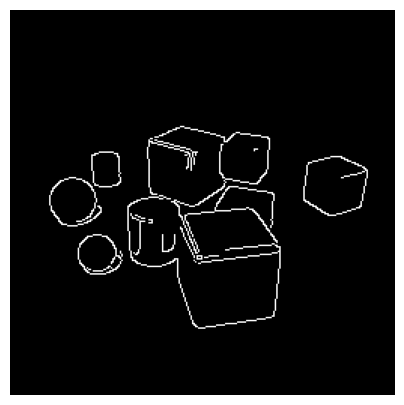

In [239]:
# no SAM, Canny only 
LOW = 100
HIGH = 200
edges = cv2.Canny(resized_numpy, LOW, HIGH)

plt.figure(figsize=(5, 5))
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()